# **Atividade Prática**
<font size=3>

- **Tema:** *word-embedding*.
- **Prazo de entrega:** 25 de Maio.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSfhkf8HoNNsr9WixEVVlxh8-pFK-rnXsLKN_OLRH_Tg5-5SmA/viewform?usp=sharing&ouid=111377632325147218671).

---

## **Questão 1:**
<font size=3>

Com base no *dataset* de [Transcrição de TED Talks](https://www.kaggle.com/datasets/miguelcorraljr/ted-ultimate-dataset), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos para resolver a **tarefa de regressão**:

### **1º Passo:**

<font size=3>

- Importe o *dataset* e defina o atributo `description` como a lista de dados textuais e `views` como a variável alvo para regressão;
- **Imprima na tela** o tamanho mínimo, o máximo e a média do comprimento das sentenças.


In [1]:
# Os arquivos estão disponiveis localmente, não é necessario montar o drive
#from google.colab import drive
#drive.mount('/content/drive/')

In [2]:
from keras import layers, Model
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib.ticker import FuncFormatter
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


In [3]:
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', None) 
df = pd.read_csv('./dataset/ted_talks.csv')
df.head()[['description', 'views']]

,description,views
0,"With the same humor and humanity he exuded in ""An Inconvenient Truth,"" Al Go...",3523392
1,You've never seen data presented like this. With the drama and urgency of a ...,14501685
2,New York Times columnist David Pogue takes aim at technology’s worst interfa...,1920832
3,"In an emotionally charged talk, MacArthur-winning activist Majora Carter det...",2664069
4,Sir Ken Robinson makes an entertaining and profoundly moving case for creati...,65051954


In [4]:
X = df['description']
y = df['views']

X_len = X.str.len()

print(f"Tamanho mínimo: {X_len.min()}")
print(f"Tamanho máximo: {X_len.max()}")
print(f"Tamanho médio.: {X_len.mean():.0f}")
print(f"Mediana.......: {X_len.median():.0f}")
print(f"Desvio padrão.: {X_len.std():.0f}")


Tamanho mínimo: 52
Tamanho máximo: 907
Tamanho médio.: 353
Mediana.......: 349
Desvio padrão.: 116


### **2º Passo:**

<font size=3>

- **2.1**: Realize a normalização da variável alvo (considerando sua adequação à função de atividação da camada de saída);
- **2.2**: Defina o objeto da vetorização dos dados textuais com a função [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/):
    - A variável `standardize` tem como *default* `"lower_and_strip_punctuation"`, mas esta variável pode receber um pré-processador customizado com *regex*, por exemplo:
    
  <font size=2>
  
  ```python
  
        import tensorflow.strings as tf_strings
        
        def Preprocessor(x):
        
            x = tf.strings.lower(x)
            x = tf.strings.regex_replace(x, r"[^\w\s]", "")
    
            return x
            
    ```
    <font size=3>
  
    - Defina o tamanho do vocabulário (`vocab_size`), o tamanho da entrada/janela do modelo (`max_len`), e a dimensão do vetor *embedding* (`embed_dim`);
    - Iremos realizar a vetorização (indexação) dentro da rede neural, ou seja, o objeto da vetorização irá processar os dados após a camada `layers.Input()`.
    <br>

- **2.3**: Divida os dados em treinamento (90%) e teste (10%). Os dados de validação serão divididos na função `model.fit()`. 

#### **2.1**: Normalização da variável alvo

Para propor uma normalização vamos primeiro analisar a distribuição dos dados de views. Para isso vamos criar uma função auxiliar que mostra uma breve descrição estatística da amostra.

In [5]:
def br_number(value, decimals=0):
    '''
    Formata um número para o formato brasileiro com a quantidade de casas decimais desejada.
    '''
    formatted = f"{value:,.{decimals}f}"
    return formatted.replace(",", "X").replace(".", ",").replace("X", ".")

In [6]:
def descrever_variavel_numerica(y, nome="variável", decimals=0):
    '''
    Descreve uma variável numérica com percentis e assimetria.
    '''
    percentis = [0, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00]

    print(f"=== Percentis de {nome} ===")

    for p in percentis:
        valor = y.quantile(p)
        qtd_acumulada = (y <= valor).sum()

        print(
            f"P {int(p * 100):>3}%:"
            f" {br_number(valor, decimals):>15}"
            f" | qtd acumulada: {qtd_acumulada:>5}"
        )

    print()

    print(f"=== Assimetria de {nome} ===")
    print(f"{'Média':<10}: {br_number(y.mean(), decimals):>15}")
    print(f"{'Mediana':<10}: {br_number(y.median(), decimals):>15}")
    print(f"{'Mínimo':<10}: {br_number(y.min(), decimals):>15}")
    print(f"{'Máximo':<10}: {br_number(y.max(), decimals):>15}")
    print(f"{'Skewness':<10}: {br_number(y.skew(), 2):>15}")
    print()

E executamos a função para a variavel numérica ```y```

In [7]:
descrever_variavel_numerica(y, "views")

=== Percentis de views ===
P   0%:               0 | qtd acumulada:     6
P   1%:          39.088 | qtd acumulada:    41
P   5%:         296.171 | qtd acumulada:   201
P  10%:         466.915 | qtd acumulada:   401
P  25%:         882.069 | qtd acumulada:  1002
P  50%:       1.375.508 | qtd acumulada:  2003
P  75%:       2.133.110 | qtd acumulada:  3004
P  90%:       3.994.610 | qtd acumulada:  3604
P  95%:       6.182.301 | qtd acumulada:  3804
P  99%:      16.299.834 | qtd acumulada:  3964
P 100%:      65.051.954 | qtd acumulada:  4005

=== Assimetria de views ===
Média     :       2.148.006
Mediana   :       1.375.508
Mínimo    :               0
Máximo    :      65.051.954
Skewness  :            8,19



Temos uma métrica de assimetria (skewness) indicando que a distribuição tem forte desvio positivo. Vamos investigar melhor essa distribuição através de um histograma onde marcaremos também os principais percentis. Para isso também vamos criar uma função que exibe um histograma dos dados, juntamente com os percentis que desejamos marcar no grafico.

In [8]:
def formatar_milhoes_br(x, pos):
    '''
    Formata um número para o formato brasileiro com a quantidade de casas decimais desejada.
    '''
    return f"{x / 1_000_000:.1f}".replace(".", ",")


def plotar_histograma_com_percentis(
    y,
    nome="variável",
    limite_percentil=0.99,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=True
):
    '''
    Plota um histograma dos dados, juntamente com os percentis que desejamos marcar no grafico.
    '''
    limite = y.quantile(limite_percentil)
    y_filtrado = y[y <= limite]

    plt.figure(figsize=(12, 6))
    plt.hist(y_filtrado, bins=bins, edgecolor="black", alpha=0.7)

    if usar_milhoes:
        plt.gca().xaxis.set_major_formatter(FuncFormatter(formatar_milhoes_br))
        xlabel = f"{nome} em milhões"
    else:
        xlabel = nome

    altura_max = plt.ylim()[1]

    for p in percentis_marcados:
        valor = y.quantile(p)

        if valor <= limite:
            plt.axvline(valor, linestyle="--", linewidth=1.5, alpha=0.8)
            plt.text(
                valor,
                altura_max * 0.95,
                f"P{int(p * 100)}",
                rotation=90,
                ha="center",
                va="top"
            )

    plt.title(f"Distribuição de {nome} até o percentil {int(limite_percentil * 100)}")
    plt.xlabel(xlabel)
    plt.ylabel("Frequência")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

E geramos o histograma a partir de ```y```

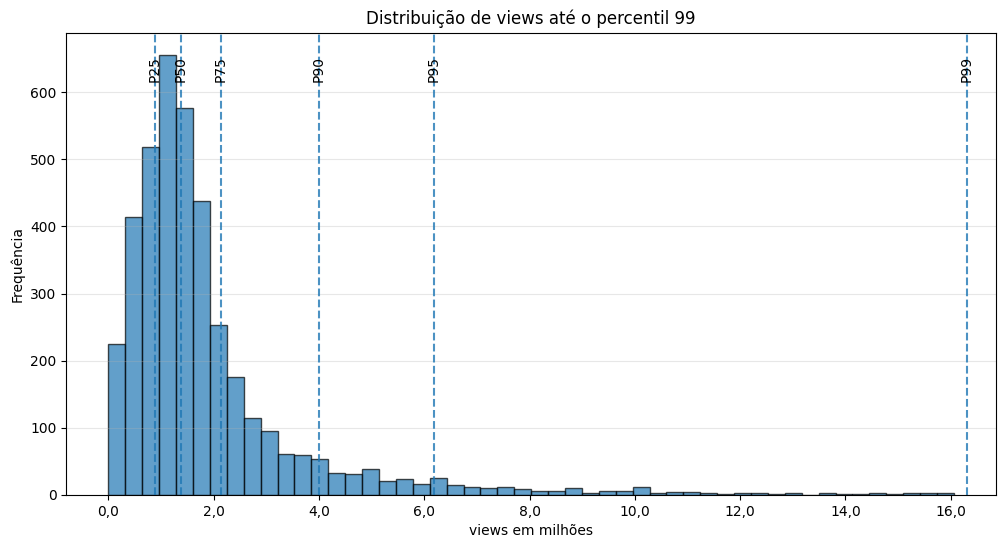

In [9]:
plotar_histograma_com_percentis(y, nome="views")

A distribuição de views apresenta forte assimetria positiva. Embora 75% dos registros estejam abaixo de aproximadamente 2,1 milhões de visualizações, os percentis superiores crescem rapidamente, chegando a cerca de 16,3 milhões no P99 e 65 milhões no valor máximo. 

Isso indica que uma normalização MinMax direta seria fortemente influenciada pelos valores extremos, comprimindo a maior parte dos dados em uma faixa pequena. Assim, faz sentido investigar uma transformação logarítmica, que pode reduzir o efeito da cauda longa antes do treinamento da rede neural.

Primeiro executamos a transformação ```np.log1p(y)```, que conforme sua definição, aplicará a função abaixo a y: $$y\_log = log_e(1 + y)$$

In [10]:
y_log = np.log1p(y)

Em seguida vamos descrever a nova variável numérica y_log:

In [11]:

descrever_variavel_numerica(y_log, "log1p(views)", decimals=2)

=== Percentis de log1p(views) ===
P   0%:            0,00 | qtd acumulada:     6
P   1%:           10,57 | qtd acumulada:    41
P   5%:           12,60 | qtd acumulada:   201
P  10%:           13,05 | qtd acumulada:   401
P  25%:           13,69 | qtd acumulada:  1002
P  50%:           14,13 | qtd acumulada:  2003
P  75%:           14,57 | qtd acumulada:  3004
P  90%:           15,20 | qtd acumulada:  3604
P  95%:           15,64 | qtd acumulada:  3804
P  99%:           16,61 | qtd acumulada:  3964
P 100%:           17,99 | qtd acumulada:  4005

=== Assimetria de log1p(views) ===
Média     :           14,10
Mediana   :           14,13
Mínimo    :            0,00
Máximo    :           17,99
Skewness  :           -3,52



E também gerar o respectivo histograma de y_log:

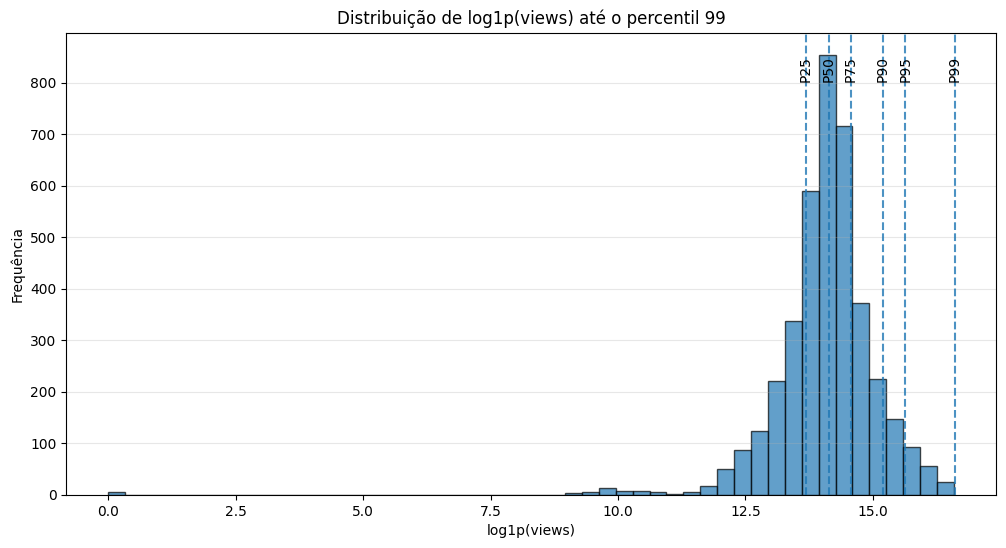

In [12]:
plotar_histograma_com_percentis(
    y_log,
    nome="log1p(views)",
    usar_milhoes=False
)

Mesmo após a transformação ```np.log1p(y)```, ainda existem valores extremos, principalmente associados aos registros com views = 0 e aos valores mais altos da distribuição. No entanto, a transformação logarítmica reduziu de forma relevante a cauda longa original.

Como o modelo será treinado por uma rede neural, também faz sentido aplicar uma normalização MinMax sobre ```np.log1p(y)```, colocando a variável alvo em uma faixa numérica controlada entre 0 e 1. Isso trata a escala numérica de forma a facilitar o aprendizado da rede neural.

Assim, combinamos duas etapas com objetivos diferentes: a transformação logarítmica reduz a assimetria da distribuição, enquanto a normalização MinMax ajusta a escala da variável para o treinamento do modelo.

É importante lembrar que a rede neural aprenderá o alvo transformado. Logo, para obter o valor original de views, será necessário aplicar as transformações inversas na ordem correta: primeiro a inversa do ```MinMaxScaler``` e depois ```np.expm1```.

Vamos aplicar a seguir a transformação ```MinMaxScaler``` sobre ```np.log1p(y)```:

In [13]:
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(
        y_log.values.reshape(-1, 1) # reshape para 2D necessario para o fit_transform
    ).ravel() #ravel para retornar um array unidimensional

y_scaled = pd.Series(y_scaled, index=y.index, name="MinMaxScaler(log1p(views))")

E descrever o resultado final nos mesmos termos que ocupamos antes para deixar registro:

In [14]:
descrever_variavel_numerica(
    y_scaled,
    "MinMax(log1p(views))",
    decimals=2
)

=== Percentis de MinMax(log1p(views)) ===
P   0%:            0,00 | qtd acumulada:     6
P   1%:            0,59 | qtd acumulada:    41
P   5%:            0,70 | qtd acumulada:   201
P  10%:            0,73 | qtd acumulada:   401
P  25%:            0,76 | qtd acumulada:  1002
P  50%:            0,79 | qtd acumulada:  2003
P  75%:            0,81 | qtd acumulada:  3004
P  90%:            0,84 | qtd acumulada:  3604
P  95%:            0,87 | qtd acumulada:  3804
P  99%:            0,92 | qtd acumulada:  3964
P 100%:            1,00 | qtd acumulada:  4005

=== Assimetria de MinMax(log1p(views)) ===
Média     :            0,78
Mediana   :            0,79
Mínimo    :            0,00
Máximo    :            1,00
Skewness  :           -3,52



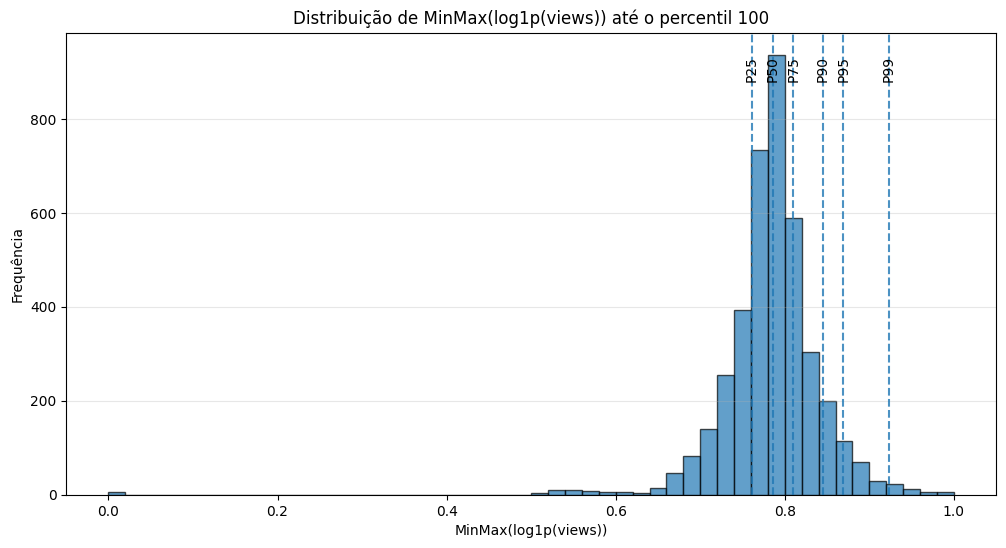

In [15]:
plotar_histograma_com_percentis(
    y_scaled,
    nome="MinMax(log1p(views))",
    limite_percentil=1.00,
    percentis_marcados=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99],
    bins=50,
    usar_milhoes=False
)

Podemos observar que o formato do histograma continua igual ao anterior, bem como a métrica de assimetria (skewness), modificando apenas a escala numérica, agora entre 0 e 1. Esse era justamente o objetivo da última transformação. 

**A partir deste ponto, nossa variável alvo passa a ser ```y_scaled```. Para obter a previsão original em views, será necessário aplicar a transformação inversa na ordem correta: primeiro a inversa do ```MinMaxScaler``` e depois ```np.expm1```.** 

Pode haver um erro desprezível devido a arredondamento e/ou precisão numérica nessa transformação inversa, mas isso é aceitável.

#### **2.2**: Definição de vetorização textual

Primeiro definimos nossa função de pré-processamento. Vamos deixar a função externalizada para facilitar modificações futuras, caso seja necessário ajustar alguma regex por qualquer motivo.

In [16]:
def Preprocessor(x):

    x = tf.strings.lower(x)
    x = tf.strings.regex_replace(x, r"[^\w\s]", "")
    x = tf.strings.regex_replace(x, r" {2,}", " ")
    x = tf.strings.strip(x)

    return x

print (Preprocessor("   Hello,   the  world's  !   ").numpy().decode("utf-8"))

hello the worlds


Em seguida definimos nosso vetorizador textual e algumas constantes utilizadas ao longo do processo.

In [17]:
VOCAB_SIZE = 10000
MAX_LEN = 100
# vamos manter o padrão de 100 dimensões para embedding por conta da questão 2, cujo GloVe possui 100 dimensões tambem
EMBED_DIM = 100 

text_vectorizer = layers.TextVectorization(
    name="TextVectorizer",
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_LEN,
    standardize=Preprocessor
)

#### **2.3**: Divisão de dados em treinamento e validação

Vamos utilizar a função [```train_test_split```](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do scikit-learn para separar os conjuntos de treino e teste.

In [18]:
RANDOM_STATE = 42
TEST_SIZE = 0.10

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_scaled,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

Por fim, descobrimos o vocabulário a partir do conjunto de treinamento, deixando propositadamente o conjunto de validação de fora:

In [19]:
text_vectorizer.adapt(X_train)

Definimos uma função simples para exibir uma amostragem do vocabulario aprendido:

In [20]:
def mostrar_amostra_vocabulario(vocab, n=10, random_state=42):
    tokens_especiais = ["", "[UNK]"]

    vocab_tokens = [
        str(token) for token in vocab
        if token not in tokens_especiais
    ]

    n = min(n, len(vocab_tokens))

    rng = np.random.default_rng(random_state)

    df_vocab = pd.DataFrame({
        "top": vocab_tokens[:n],
        "bottom": vocab_tokens[-n:],
        "random": rng.choice(vocab_tokens, size=n, replace=False).tolist()
    })

    print("=== Amostra do vocabulário aprendido ===")
    print(f"Tamanho total do vocabulário: {len(vocab)}")
    print(f"Tamanho sem tokens especiais: {len(vocab_tokens)}")
    print(f"Retornando DataFrame com N={n} tokens top, bottom e random.")

    return df_vocab

E mostramos os N top/bottom tokens e os N tokens aleatorios do vocabulário.

In [21]:
N=10
df_vocab = mostrar_amostra_vocabulario(
    text_vectorizer.get_vocabulary(),
    n=N,
    random_state=RANDOM_STATE
)

df_vocab.head(N)

=== Amostra do vocabulário aprendido ===
Tamanho total do vocabulário: 10000
Tamanho sem tokens especiais: 9998
Retornando DataFrame com N=10 tokens top, bottom e random.


,top,bottom,random
0,the,completing,minds
1,and,competitor,slogan
2,of,competitions,robert
3,to,compelled,frontlines
4,a,comparing,devastation
5,in,compare,explosion
6,that,companions,bay
7,by,communicates,complicated
8,for,commonsense,greater
9,how,commits,mistry


### **3º Passo:**

<font size=3>

- **3.1**: Desenvolva a primeira versão da **arquitetura neural**:
    - Já sabemos o tamanho da entrada, o tamanho da saída e sua função de ativação:
 
        <font size=2>
        
        ```python
        x_in = layers.Input(shape=(1, ), dtype=tf.string)
            
        ```
        <font size=3>
        
    - A camada [`Embedding`](https://keras.io/api/layers/core_layers/embedding/) irá retornar um *array* de formato (`max_len`, `embed_dim`), assim, precisamos torná-lo unidimensional para poder ser acoplado à próxima camada. Para isso, utilize:
        - Uma camada de [`Flatten`](https://keras.io/api/layers/reshaping_layers/flatten/);
        - Ou uma camada de [`GlobalAveragePooling1D`](https://keras.io/api/layers/pooling_layers/global_average_pooling1d/).
        <br>

- **3.2**: **Escreva** em uma **célula _markdown_** a diferença entre as camadas `Flatten` e `GlobalAveragePooling1D`;

- **3.3**: Compile o modelo com um otimizador ([`SGR`](https://keras.io/api/optimizers/sgd/), [`RMSprop`](https://keras.io/api/optimizers/rmsprop/), [`Adam`](https://keras.io/api/optimizers/adam/));
- **3.4**: Defina a função de perda e métrica de acordo com a natureza do problema.
  

#### **3.1**: Desenvolvimento da primeira versão da **arquitetura neural**

Como a questão seguinte solicita explicação sobre a diferença entre GlobalAveragePooling1D e Flatten, vamos desenvolver um núcleo comum de processamento de embedding primeiro.

In [22]:
x_in = layers.Input(
    shape=(1,), 
    dtype=tf.string,
    name="Entrada de dados")

x = text_vectorizer(x_in)

x = layers.Embedding(
    name="Gerador de Embedding",
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM
)(x)

Em seguida vamos criar dois fluxos paralelos, um com GlobalAveragePooling1D e outro com Flatten, sufixando as respectivas variáveis.

In [23]:
x_pooling = layers.GlobalAveragePooling1D(name="Representação vetorial")(x)
x_flatten = layers.Flatten(name="Representação vetorial")(x)

x_pooling = layers.Dense(64, activation="relu", name="Camada densa 1")(x_pooling)
x_flatten = layers.Dense(64, activation="relu", name="Camada densa 1")(x_flatten)

x_pooling = layers.Dense(32, activation="relu", name="Camada densa 2")(x_pooling)
x_flatten = layers.Dense(32, activation="relu", name="Camada densa 2")(x_flatten)

y_out_pooling = layers.Dense(1, activation="linear", name="Saída")(x_pooling)
y_out_flatten = layers.Dense(1, activation="linear", name="Saída")(x_flatten)

Por fim criamos o primeiro modelo com o GlobalAveragePooling1D:

In [24]:
model_pooling = Model(
    name="Modelo de regressão com embedding + GlobalAveragePooling1D",
    inputs=x_in, 
    outputs=y_out_pooling)

model_pooling.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_pooling.summary()

Model: "Modelo de regressão com embedding + GlobalAveragePooling1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada de dados (InputLayer)   │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TextVectorizer                  │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Gerador de Embedding            │ (None, 100, 100)       │     1,000,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Representação vetorial          │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Camada densa 1 (Dense)          │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Camada densa 2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saída (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,008,577 (3.85 MB)

 Trainable params: 1,008,577 (3.85 MB)

 Non-trainable params: 0 (0.00 B)

E finalizamos com o modelo utilizando Flatten:

In [25]:

model_flatten = Model(
    name="Modelo de regressão com embedding + Flatten",
    inputs=x_in, 
    outputs=y_out_flatten)

model_flatten.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model_flatten.summary()


Model: "Modelo de regressão com embedding + Flatten"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada de dados (InputLayer)   │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TextVectorizer                  │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Gerador de Embedding            │ (None, 100, 100)       │     1,000,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Representação vetorial          │ (None, 10000)          │             0 │
│ (Flatten)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Camada densa 1 (Dense)          │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Camada densa 2 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saída (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,642,177 (6.26 MB)

 Trainable params: 1,642,177 (6.26 MB)

 Non-trainable params: 0 (0.00 B)

#### **3.2**: Explicando diferença entre `Flatten` e `GlobalAveragePooling1D`

Para explicar a diferenção entre `GlobalAveragePooling1D` e `Flatten` vamos primeiro montar uma tabela comparativa dos dois modelos, onde pareamos para cada etapa do modelo as dimensões de saída e a quantidade de parâmetros correspondente, quando aplicável.

Primeiro criamos uma função que extrai os dados relevantes de um modelo:

In [26]:
def extrair_resumo_modelo(model, nome_coluna):
    dados = []

    for ordem, layer in enumerate(model.layers):
        dados.append({
            "Ordem": ordem,
            "Camada": layer.name,
            f"Saída {nome_coluna}": str(layer.output.shape),
            f"Parâmetros {nome_coluna}": layer.count_params()
        })

    return pd.DataFrame(dados)

Aplicamos a função para os dois modelos:

In [27]:
df_pooling = extrair_resumo_modelo(model_pooling, "Pooling 1D")
df_flatten = extrair_resumo_modelo(model_flatten, "Flatten")

Juntamos os dois dataframes para permitir a comparação e exibimos o resultado:

In [28]:
df_comparacao = pd.merge(
    df_pooling,
    df_flatten,
    on=["Ordem", "Camada"],
    how="outer"
)

df_comparacao = df_comparacao.sort_values("Ordem").drop(columns="Ordem")

df_comparacao

,Camada,Saída Pooling 1D,Parâmetros Pooling 1D,Saída Flatten,Parâmetros Flatten
0,Entrada de dados,"(None, 1)",0,"(None, 1)",0
1,TextVectorizer,"(None, 100)",0,"(None, 100)",0
2,Gerador de Embedding,"(None, 100, 100)",1000000,"(None, 100, 100)",1000000
3,Representação vetorial,"(None, 100)",0,"(None, 10000)",0
4,Camada densa 1,"(None, 64)",6464,"(None, 64)",640064
5,Camada densa 2,"(None, 32)",2080,"(None, 32)",2080
6,Saída,"(None, 1)",33,"(None, 1)",33


Através de uma simples observação, podemos identificar que a principal diferença numérica entre as duas abordagens está na quantidade de parâmetros da Camada densa 1. Enquanto `GlobalAveragePooling1D` gera apenas 4.160 parâmetros, `Flatten` gera 409.664 parâmetros: uma diferença muito grande. A seguir explicamos o motivo dessa diferença.

A operação `Flatten` simplesmente concatena os vetores que representam cada token da descrição. Como cada descrição foi limitada a 100 tokens e cada token é representado por um vetor de 64 posições, a saída da camada de embedding possui formato (100, 64). Ao aplicar `Flatten`, essa matriz é achatada em um único vetor com 100 × 64 = 6.400 posições.

Já a operação `GlobalAveragePooling1D` não concatena todos os tokens. Ela calcula a média em cada posição dos vetores dos tokens, preservando as 64 dimensões do embedding. Depois dela, a descrição passa a ser representada por um único vetor de 64 posições, que pode ser entendido como uma espécie de média dos embeddings dos tokens que compõem a descrição.

Em termos numéricos, `Flatten` transforma cada descrição em um vetor com 64 × 100 = 6.400 posições, enquanto `GlobalAveragePooling1D` transforma a descrição em um vetor com apenas 64 posições, ou seja, um fator 100 vezes menor. A grande diferença na quantidade de parâmetros observada na primeira camada densa vem justamente dessa diferença no tamanho da entrada.

Do ponto de vista metodológico, as duas abordagens apresentam vantagens e desvantagens. `Flatten` mantém separadas as representações de cada posição da sequência, preservando mais informação da estrutura original da entrada, mas gera um custo computacional muito maior e aumenta o risco de overfitting, que possivelmente deverá ser mitigado. `GlobalAveragePooling1D`, por outro lado, reduz bastante esse custo ao representar a descrição por uma média dos embeddings dos tokens, mas descarta a distinção entre as posições dos tokens no texto.

Assim, a escolha entre as duas abordagens depende do objetivo do modelo e das características do problema. Para conjuntos de dados menores, como neste caso, `GlobalAveragePooling1D` tende a ser uma escolha mais simples e menos propensa ao overfitting. Já `Flatten` pode oferecer maior capacidade de representação, mas ao custo de muitos mais parâmetros.

#### **3.3**: Definindo os otimizadores SGR, RMSprop e Adam

Considerando que vamos querer testar posteriormente alguns otimizadores distintos, e possivelmente comparar a camada de representação vetorial com `Flatter` ou `GlobalAveragePooling1D`, vamos criar uma função genérica que cria o modelo recebendo os parâmetros pertinentes. O usuario da função build_model deve compilar o modelo utilizando o otimizador, função de perda e métrica desejados.

In [29]:
def build_model(
    model_name,
    representation_layer_class,
    dense_layers
):
    """
    Constrói a arquitetura neural para regressão a partir de textos.

    A função cria um modelo Keras que recebe textos brutos como entrada,
    aplica a vetorização textual previamente adaptada, gera embeddings dos
    tokens, transforma a saída do embedding em uma representação vetorial
    única e adiciona as camadas densas especificadas.

    A função não compila o modelo. A compilação deve ser feita separadamente,
    permitindo testar diferentes otimizadores, funções de perda e métricas
    sobre a mesma arquitetura.

    Parameters
    ----------
    model_name : str
        Nome atribuído ao modelo Keras.

    representation_layer_class : class
        Classe da camada responsável por transformar a saída do embedding
        em um vetor unidimensional. Exemplos:
        `layers.GlobalAveragePooling1D` ou `layers.Flatten`.

    dense_layers : list of dict
        Lista com a configuração das camadas densas intermediárias.
        Cada elemento da lista deve ser um dicionário contendo:

        - "units": quantidade de neurônios da camada;
        - "activation": função de ativação da camada.

        Exemplo:
        [
            {"units": 64, "activation": "relu"},
            {"units": 32, "activation": "relu"}
        ]

    Returns
    -------
    keras.Model
        Modelo Keras ainda não compilado.
    """

    x_in = layers.Input(
        shape=(1,),
        dtype=tf.string,
        name="Entrada"
    )

    x = text_vectorizer(x_in)

    x = layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        name="Embedding"
    )(x)

    x = representation_layer_class(
        name="Representacao_vetorial"
    )(x)

    for i, layer_config in enumerate(dense_layers, start=1):
        x = layers.Dense(
            units=layer_config["units"],
            activation=layer_config["activation"],
            name=f"Dense_{i}"
        )(x)

    y_out = layers.Dense(
        1,
        activation="linear",
        name="Saida"
    )(x)

    model = Model(
        name=model_name,
        inputs=x_in,
        outputs=y_out
    )

    return model

A seguir definimos os tres otimizadores que vamos utilizar nas etapas posteriores.

In [30]:
OPTIMIZERS = {
    "SGD": lambda: tf.keras.optimizers.SGD(learning_rate=0.01),
    "RMSprop": lambda: tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": lambda: tf.keras.optimizers.Adam(learning_rate=0.001)
}

#### **3.4**: Definindo a função de perda

A função de perda adequada para o nosso contexto é a MSE (*Mean Squared Error*), dado que estamos resolvendo um problema de regressão. Também definimos como métrica o MAE (*Mean Absolute Error*), que nos permitirá acompanhar o erro absoluto médio das previsões durante o treinamento. Abaixo, criamos e compilamos os modelos com cada um dos otimizadores, utilizando a função de perda e a métrica mencionadas.

Configuramos algumas arquiteturas distintas, começando com uma camada de 32 neurônios, uma segunda opção com uma camada de 64 neurônios, concluindo com duas opções de duas camadas: 64 -> 32 e 128 -> 64. Escolhemos propositadamente multiplos da dimensão dos embeddings nessas arquiteturas. Ao final vamos treinar todas as combinações de arquiteturas e otimizadores definidos anteriormente, um total de 12 opções.

In [31]:
DENSE_LAYER_CONFIGS = {
    "32_relu": [
        {"units":  32, "activation": "relu"}
    ],
    "64_relu": [
        {"units":  64, "activation": "relu"}
    ],
    "64_32_relu": [
        {"units":  64, "activation": "relu"},
        {"units":  32, "activation": "relu"}
    ],
    "128_64_relu": [
        {"units": 128, "activation": "relu"},
        {"units":  64, "activation": "relu"}
    ]
}

models = {}

for dense_config_name, dense_layers in DENSE_LAYER_CONFIGS.items():
    for optimizer_name, optimizer_fn in OPTIMIZERS.items():

        tf.keras.utils.set_random_seed(RANDOM_STATE)

        experiment_name = f"{dense_config_name}_{optimizer_name.lower()}"

        model = build_model(
            model_name=f"model_global_avg_pooling_{experiment_name}",
            representation_layer_class=layers.GlobalAveragePooling1D,
            dense_layers=dense_layers
        )

        model.compile(
            optimizer=optimizer_fn(),
            loss="mse",
            metrics=["mae"]
        )

        models[experiment_name] = {
            "model": model,
            "dense_config": dense_config_name,
            "optimizer": optimizer_name,
            "dense_layers": dense_layers
        }

### **4º Passo:**
<font size=3>

- Treine o modelo com o método `.fit()`, definindo as variáveis:
    - `validation_split`: porcentagem de dados para validação;
    - `epochs`: número de épocas para o treinamento;
    - `batch_size`: tamanho do lote da amostragem dos dados de entrada.
      

#### **4.1**: Treinando cada um dos 12 modelos

Primeiro formatamos os dados para entrada no modelo.

In [32]:
X_train_model = tf.convert_to_tensor(
    X_train.astype(str).to_numpy().reshape(-1, 1),
    dtype=tf.string
)

y_train_model = tf.convert_to_tensor(
    y_train.to_numpy().reshape(-1, 1),
    dtype=tf.float32
)

Em seguida executamos o treinamento com split de validação de 10%, 30 épocas e batch size de 32.

In [33]:
VALIDATION_SPLIT = 0.10
EPOCHS = 30
BATCH_SIZE = 32

histories = {}

for experiment_name, experiment in models.items():
    model = experiment["model"]

    print(f"\n=== Treinando {experiment_name} ===")

    history = model.fit(
        X_train_model,
        y_train_model,
        validation_split=VALIDATION_SPLIT,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    histories[experiment_name] = {
        "history": history,
        "dense_config": experiment["dense_config"],
        "optimizer": experiment["optimizer"],
        "dense_layers": experiment["dense_layers"]
    }


=== Treinando 32_relu_sgd ===
Epoch 1/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1010 - mae: 0.2386 - val_loss: 0.0053 - val_mae: 0.0570
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0050 - mae: 0.0491 - val_loss: 0.0048 - val_mae: 0.0521
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0047 - mae: 0.0470 - val_loss: 0.0045 - val_mae: 0.0504
Epoch 4/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0046 - mae: 0.0455 - val_loss: 0.0044 - val_mae: 0.0490
Epoch 5/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0044 - mae: 0.0443 - val_loss: 0.0042 - val_mae: 0.0479
Epoch 6/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0043 - mae: 0.0433 - val_loss: 0.0041 - val_mae: 0.0470
Epoch 7/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0042 - mae: 0.0425 - val_loss: 0.0040 - val_mae: 0.0462
Epoch 8/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0042 - mae: 0.0418 - val_loss: 0.0040 - val_mae: 0.0455
Epoch 9/30
102/102 ━━━━━━

#### **4.2**: Analisando o resultado dos experimentos

Definimos uma função para definir limites fixos da escala dos gráficos que utilizaremos nas análises. Observamos os valores minimos e máximos de loss e mse e retornamos esses valores para facilitar a análise com gráficos que utilizam a mesma escala.

In [34]:
def calcular_limites_metricas(histories, margem=0.05):
    mse_values = []
    mae_values = []

    for experiment_history in histories.values():
        history_df = pd.DataFrame(experiment_history["history"].history)

        mse_values.extend(history_df["loss"].values)
        mse_values.extend(history_df["val_loss"].values)

        mae_values.extend(history_df["mae"].values)
        mae_values.extend(history_df["val_mae"].values)

    mse_min, mse_max = min(mse_values), max(mse_values)
    mae_min, mae_max = min(mae_values), max(mae_values)

    mse_margin = (mse_max - mse_min) * margem
    mae_margin = (mae_max - mae_min) * margem

    mse_ylim = (max(0, mse_min - mse_margin), mse_max + mse_margin)
    mae_ylim = (max(0, mae_min - mae_margin), mae_max + mae_margin)

    return mse_ylim, mae_ylim

Definimos também uma função para mostrar o comportamento da loss e da métrica ao longo das épocas. Além disso mostraremos também a média das ultimas 5 épocas e o desvio padrão, mostrando lado a lado MSE e MAE.

In [35]:
def plot_training_history(history, title, mse_ylim=None, mae_ylim=None, janela=5):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # =========================
    # MSE
    # =========================
    mse_last = history_df["val_loss"].tail(janela)
    mse_mean = mse_last.mean()
    mse_std = mse_last.std()

    axes[0].plot(history_df["loss"], label="Treino")
    axes[0].plot(history_df["val_loss"], label="Validação")

    axes[0].axhline(
        mse_mean,
        linestyle="--",
        linewidth=1.5,
        label=f"Média val_loss últimas {janela}: {mse_mean:.6f}"
    )

    axes[0].axhspan(
        mse_mean - mse_std,
        mse_mean + mse_std,
        alpha=0.15,
        label=f"±1 std: {mse_std:.6f}"
    )

    axes[0].set_title("MSE")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("MSE")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if mse_ylim is not None:
        axes[0].set_ylim(mse_ylim)

    # =========================
    # MAE
    # =========================
    mae_last = history_df["val_mae"].tail(janela)
    mae_mean = mae_last.mean()
    mae_std = mae_last.std()

    axes[1].plot(history_df["mae"], label="Treino")
    axes[1].plot(history_df["val_mae"], label="Validação")

    axes[1].axhline(
        mae_mean,
        linestyle="--",
        linewidth=1.5,
        label=f"Média val_mae últimas {janela}: {mae_mean:.6f}"
    )

    axes[1].axhspan(
        mae_mean - mae_std,
        mae_mean + mae_std,
        alpha=0.15,
        label=f"±1 std: {mae_std:.6f}"
    )

    axes[1].set_title("MAE")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("MAE")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    if mae_ylim is not None:
        axes[1].set_ylim(mae_ylim)

    fig.suptitle(f"Histórico de treinamento - {title}", fontsize=14)
    plt.tight_layout()
    plt.show()

Agora executamos as funções anteriores para exibir os gráficos desejados.

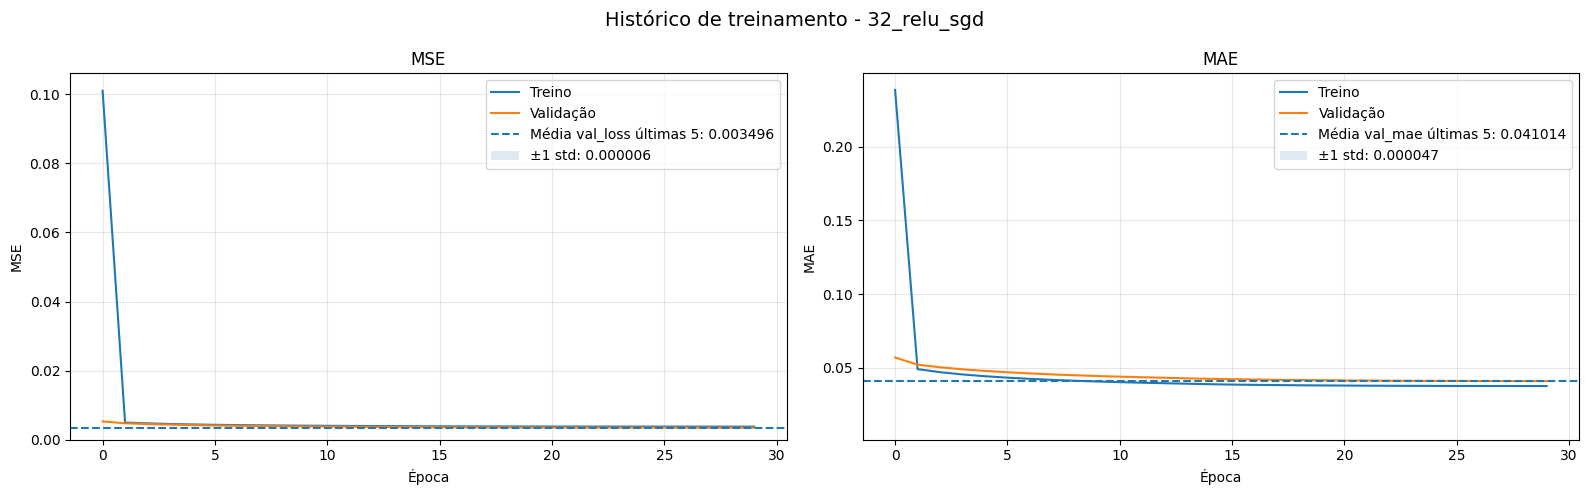

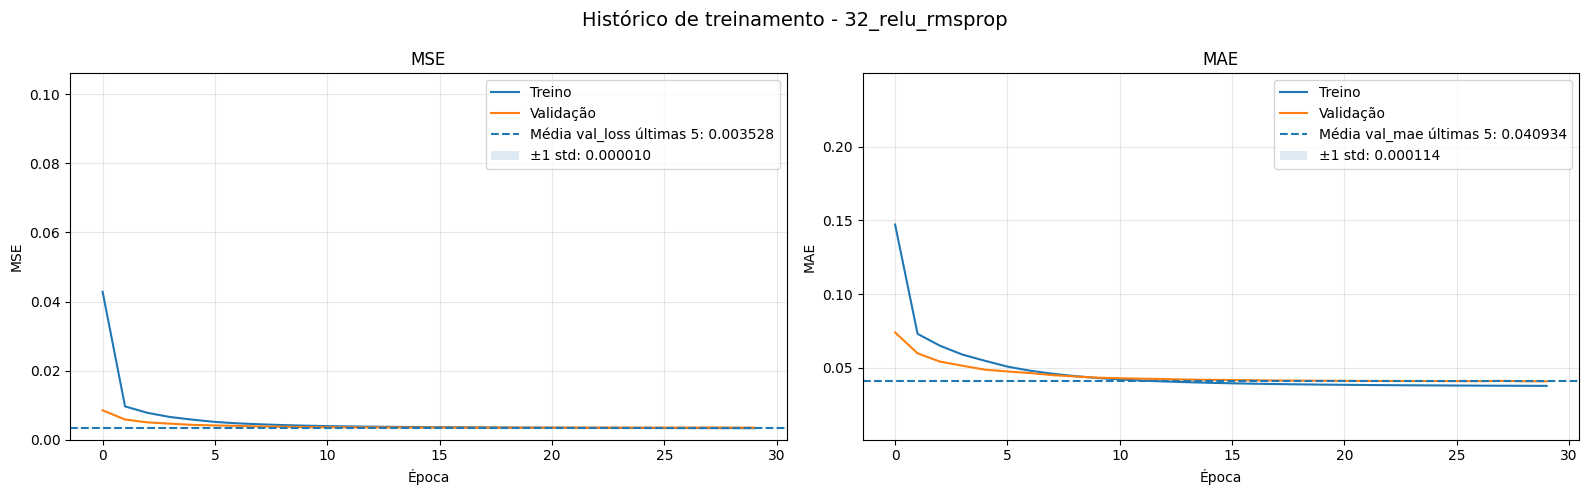

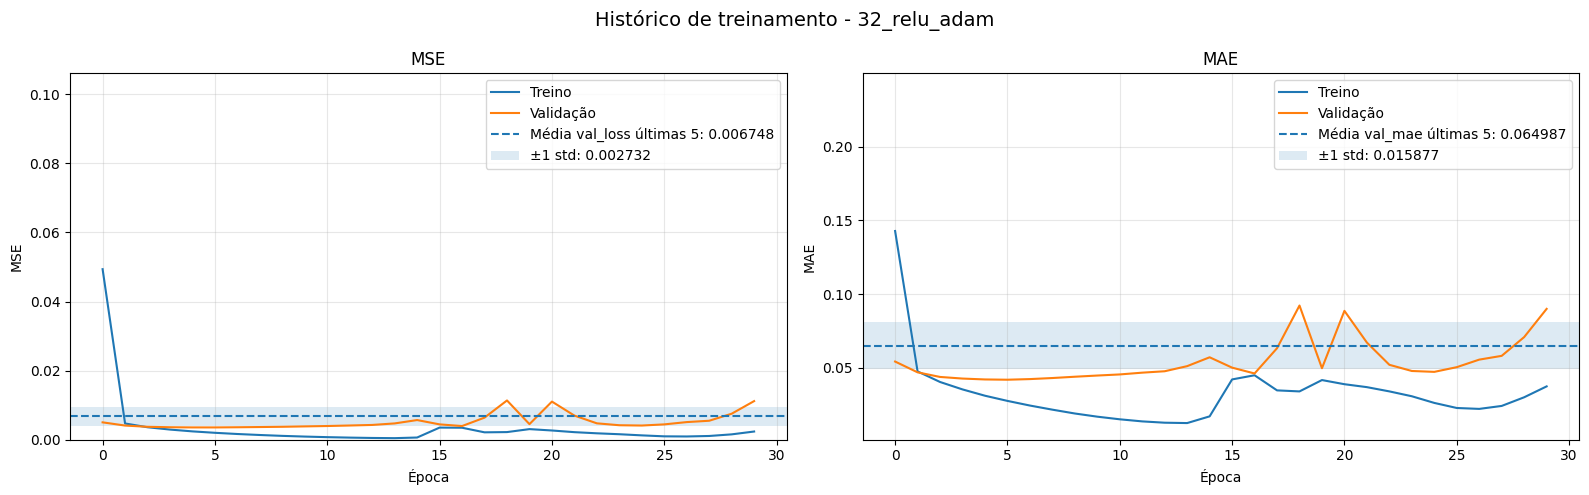

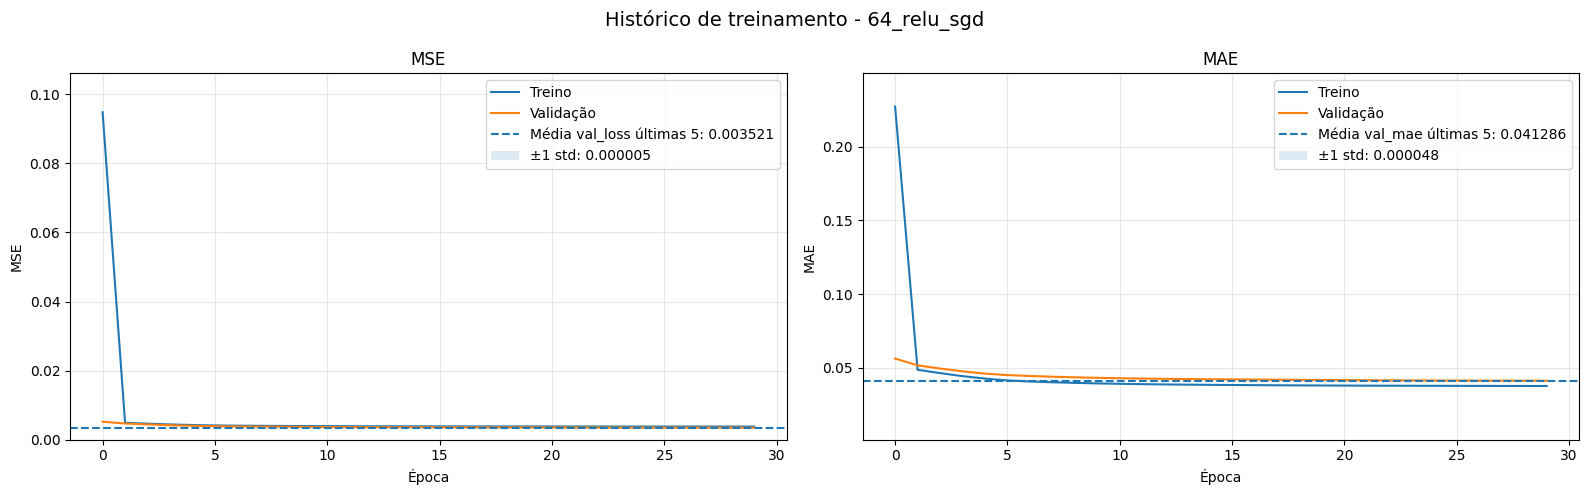

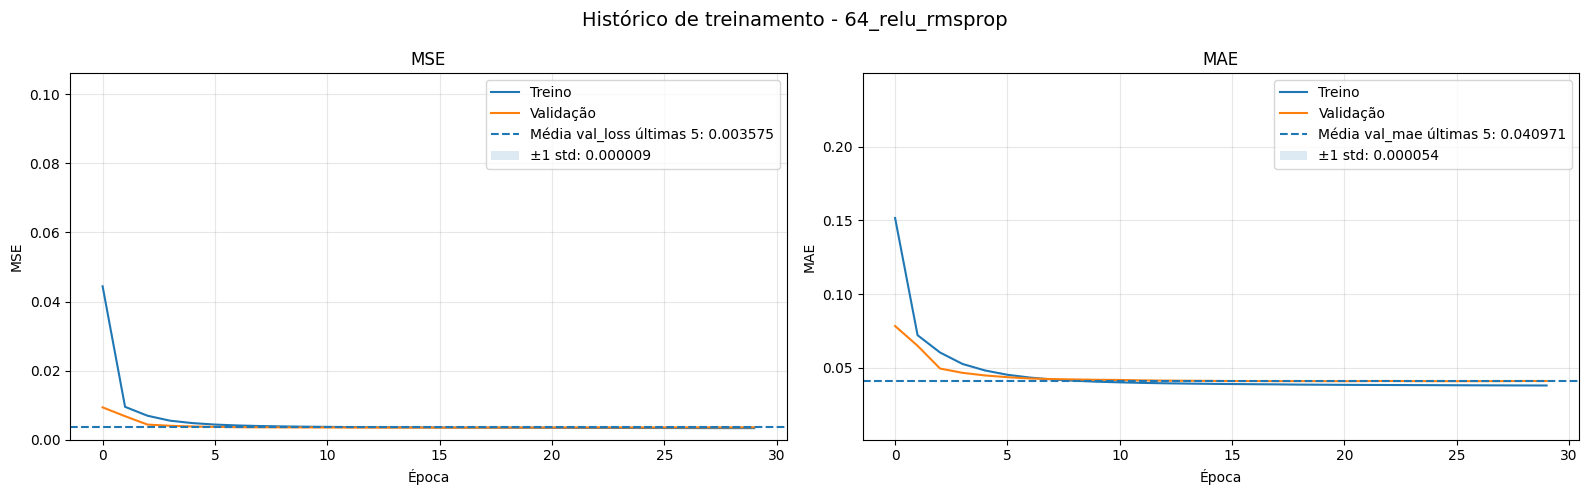

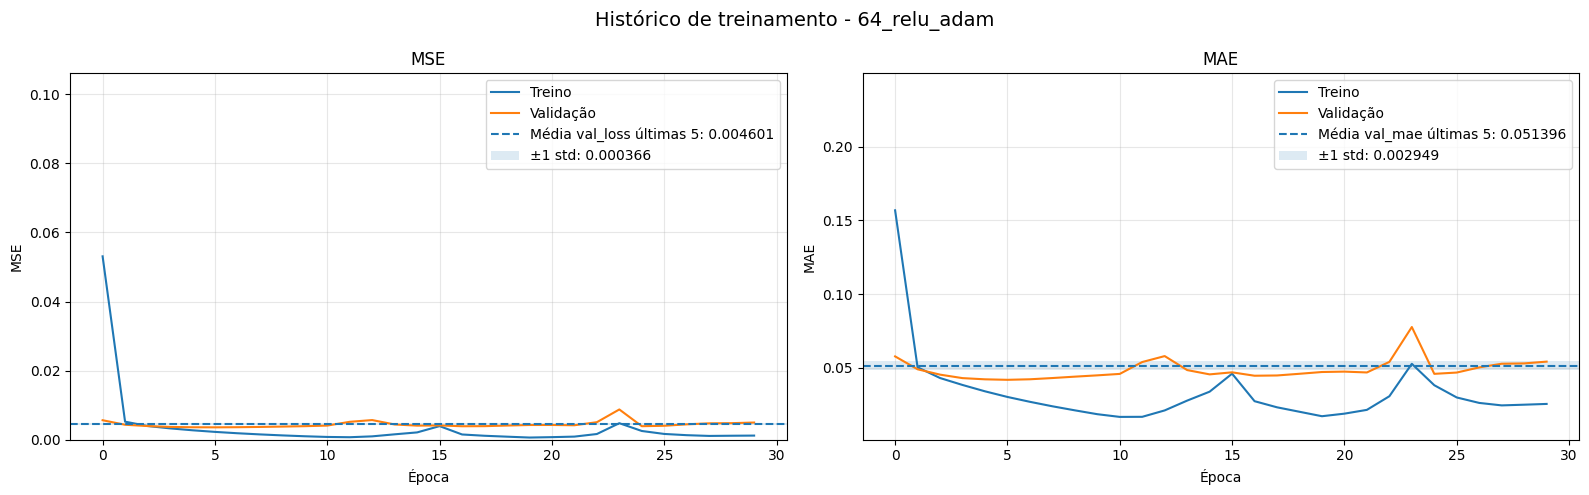

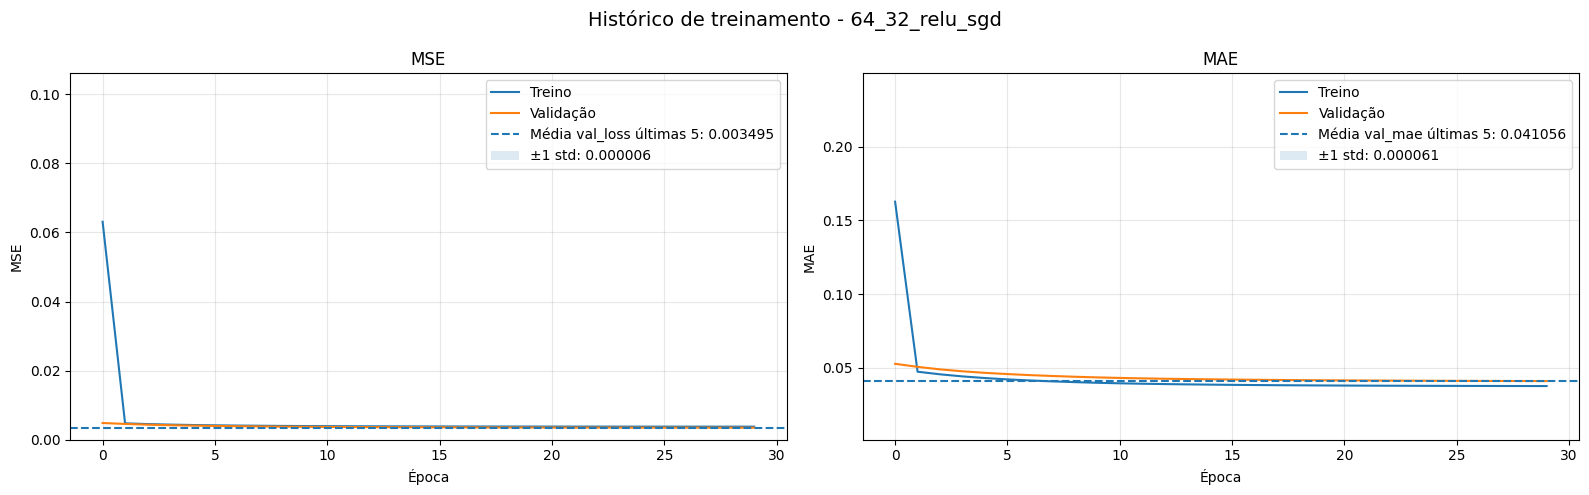

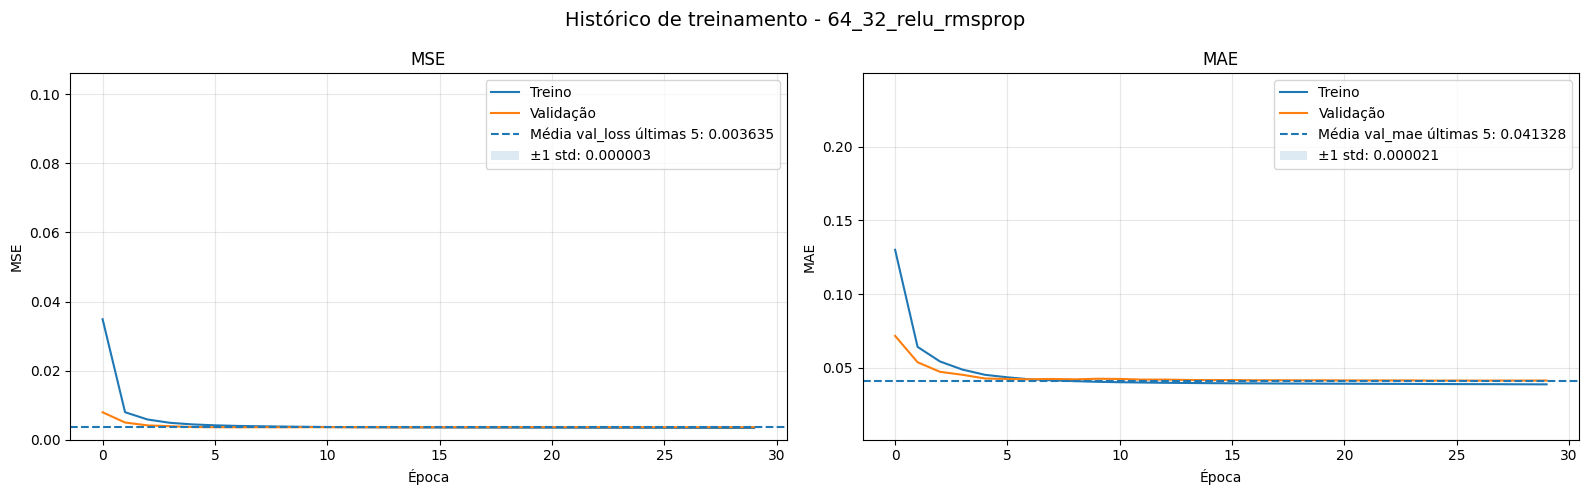

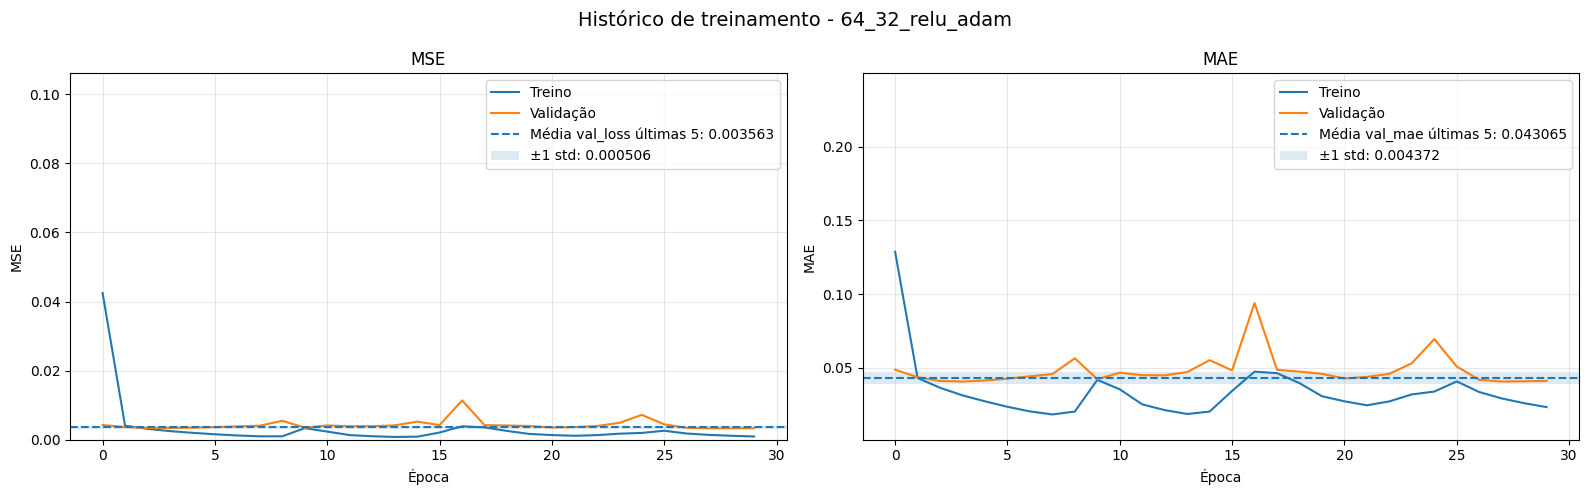

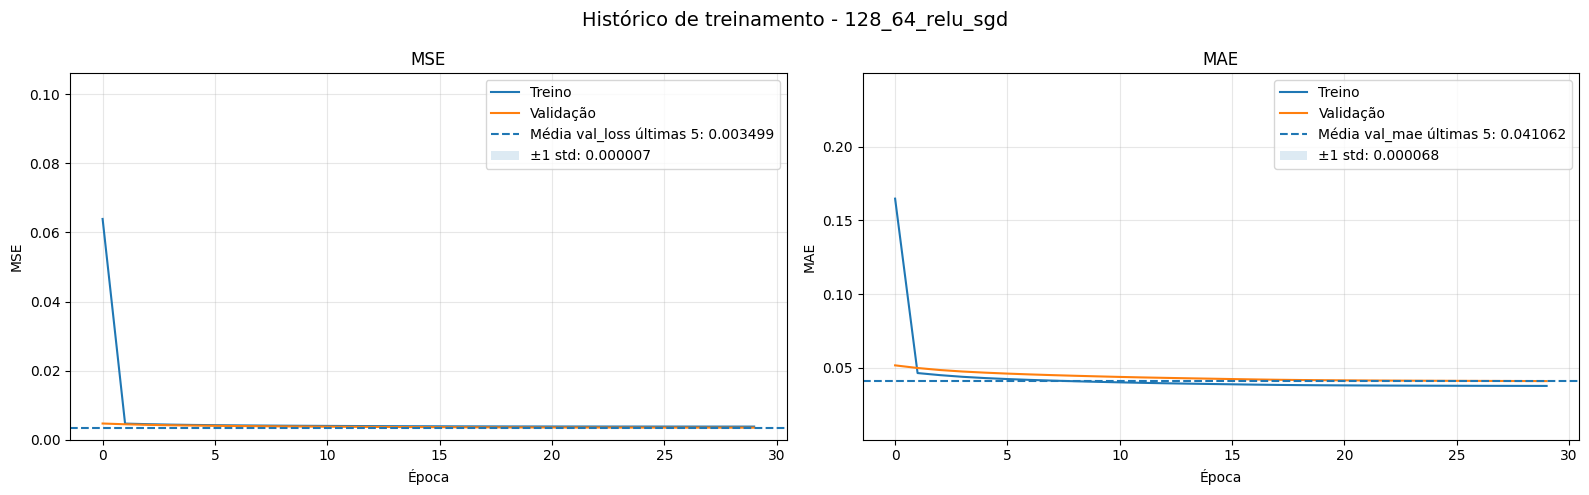

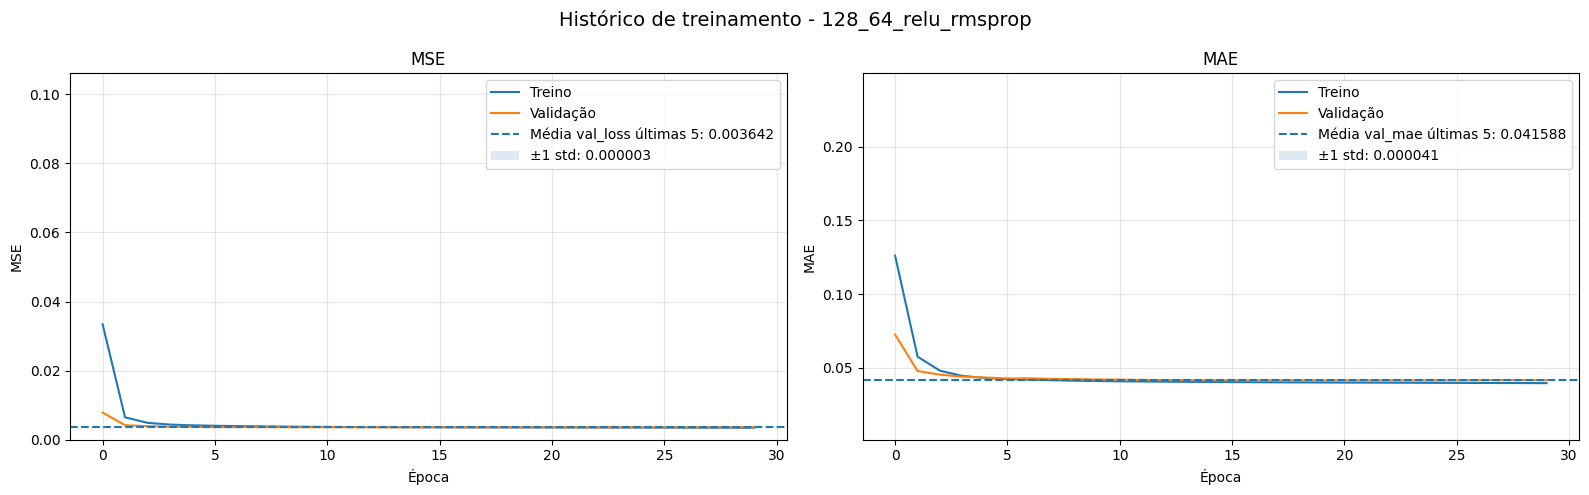

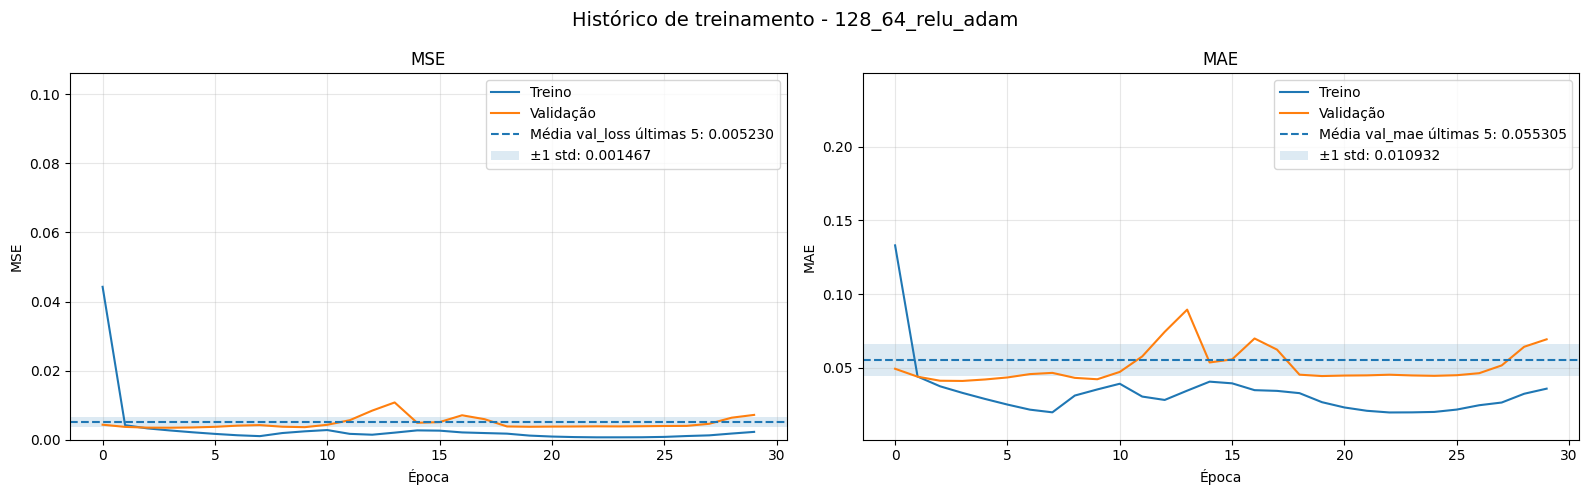

In [36]:
mse_ylim, mae_ylim = calcular_limites_metricas(histories)

for experiment_name, experiment_history in histories.items():
    plot_training_history(
        experiment_history["history"],
        title=experiment_name,
        mse_ylim=mse_ylim,
        mae_ylim=mae_ylim,
        janela=5
    )

Em seguida montamos um dataframe com os principais elementos que vamos utilizar para avaliar os experimentos: loss (MSE), métrica (MAE) da janela e da ultima época, média e desvio padrão da janela, tanto para treino quanto para validação. E terminamos com a melhor MSE e MAE e a época correspondente para a validação.

In [37]:
def gerar_dataframe_metricas_finais(histories, janela=5):
    resultados = []

    for experiment_name, experiment_history in histories.items():
        history_df = pd.DataFrame(experiment_history["history"].history)

        val_loss_last = history_df["val_loss"].tail(janela)
        val_mae_last = history_df["val_mae"].tail(janela)

        loss_last = history_df["loss"].tail(janela)
        mae_last = history_df["mae"].tail(janela)

        resultados.append({
            "experimento": experiment_name,
            "dense_config": experiment_history["dense_config"],
            "optimizer": experiment_history["optimizer"],

            "mean_val_loss_last": val_loss_last.mean(),
            "std_val_loss_last": val_loss_last.std(),
            "mean_val_mae_last": val_mae_last.mean(),
            "std_val_mae_last": val_mae_last.std(),

            "mean_train_loss_last": loss_last.mean(),
            "std_train_loss_last": loss_last.std(),
            "mean_train_mae_last": mae_last.mean(),
            "std_train_mae_last": mae_last.std(),

            "final_val_loss": history_df["val_loss"].iloc[-1],
            "final_val_mae": history_df["val_mae"].iloc[-1],
            "final_train_loss": history_df["loss"].iloc[-1],
            "final_train_mae": history_df["mae"].iloc[-1],

            "best_val_loss": history_df["val_loss"].min(),
            "best_val_loss_epoch": history_df["val_loss"].idxmin() + 1,
            "best_val_mae": history_df["val_mae"].min(),
            "best_val_mae_epoch": history_df["val_mae"].idxmin() + 1,
        })

    return (
        pd.DataFrame(resultados)
        .sort_values(
            by=[
                "mean_val_loss_last",
                "std_val_loss_last",
                "mean_val_mae_last"
            ]
        )
        .reset_index(drop=True)
    )

Ordenamos os resultados obtidos de acordo com o critério:

```python
    by=[
        "mean_val_loss_last",   # critério principal: menor MSE médio de validação nas últimas épocas
        "std_val_loss_last",    # desempate 1: menor oscilação do MSE de validação
        "mean_val_mae_last",    # desempate 2: menor MAE médio de validação
        "std_val_mae_last"      # desempate 3: menor oscilação do MAE de validação
    ]
```

In [38]:
df_metricas_finais = gerar_dataframe_metricas_finais(
    histories,
    janela=5
)

df_metricas_finais = df_metricas_finais.sort_values(
    by=[
        "mean_val_loss_last",   # critério principal: menor MSE médio de validação nas últimas épocas
        "std_val_loss_last",    # desempate 1: menor oscilação do MSE de validação
        "mean_val_mae_last",    # desempate 2: menor MAE médio de validação
        "std_val_mae_last"      # desempate 3: menor oscilação do MAE de validação
    ],
    ascending=True
).reset_index(drop=True)

df_selecao_modelos = df_metricas_finais[
    [
        "experimento",
        "dense_config",
        "optimizer",
        "mean_val_loss_last",
        "std_val_loss_last",
        "mean_val_mae_last",
        "std_val_mae_last",
        "final_val_loss",
        "final_val_mae",
        "best_val_loss",
        "best_val_loss_epoch"
    ]
]

df_selecao_modelos

,experimento,dense_config,optimizer,mean_val_loss_last,std_val_loss_last,mean_val_mae_last,std_val_mae_last,final_val_loss,final_val_mae,best_val_loss,best_val_loss_epoch
0,64_32_relu_sgd,64_32_relu,SGD,0.003495,0.000006,0.041056,0.000061,0.003488,0.040983,0.003488,30
1,32_relu_sgd,32_relu,SGD,0.003496,0.000006,0.041014,0.000047,0.003489,0.040958,0.003489,30
2,128_64_relu_sgd,128_64_relu,SGD,0.003499,0.000007,0.041062,0.000068,0.003491,0.040978,0.003491,30
3,64_relu_sgd,64_relu,SGD,0.003521,0.000005,0.041286,0.000048,0.003515,0.041228,0.003515,30
4,32_relu_rmsprop,32_relu,RMSprop,0.003528,0.000010,0.040934,0.000114,0.003526,0.040827,0.003500,22
5,64_32_relu_adam,64_32_relu,Adam,0.003563,0.000506,0.043065,0.004372,0.003327,0.041128,0.003301,28
6,64_relu_rmsprop,64_relu,RMSprop,0.003575,0.000009,0.040971,0.000054,0.003587,0.041018,0.003512,16
7,64_32_relu_rmsprop,64_32_relu,RMSprop,0.003635,0.000003,0.041328,0.000021,0.003635,0.041348,0.003597,9
8,128_64_relu_rmsprop,128_64_relu,RMSprop,0.003642,0.000003,0.041588,0.000041,0.003646,0.041616,0.003613,13
9,64_relu_adam,64_relu,Adam,0.004601,0.000366,0.051396,0.002949,0.004975,0.054194,0.003587,6


#### **4.3**: Melhor modelo escolhido

Por fim destacamos o gráfico do melhor modelo escolhido:

In [39]:
melhor_experimento = df_selecao_modelos.iloc[0]["experimento"]

melhor_experimento

'64_32_relu_sgd'

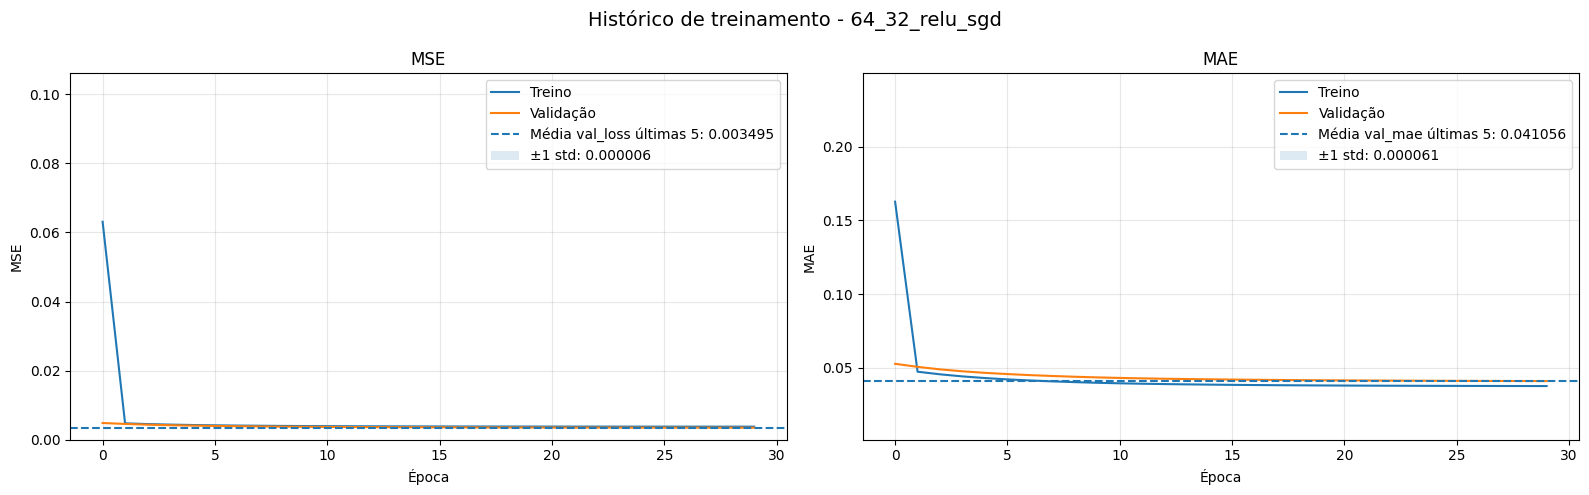

In [40]:
plot_training_history(
    histories[melhor_experimento]["history"],
    title=melhor_experimento,
    mse_ylim=mse_ylim,
    mae_ylim=mae_ylim,
    janela=5
)

### **5º Passo:**
<font size=3>

- Quando definido a melhor rede neural, realize o treinamento final.

Tomamos a configuração do modelo escolhido no passo 4, criamos e treinamos o modelo utilizando todo o conjunto de treino e validação.

In [41]:
melhor_dense_config = histories[melhor_experimento]["dense_config"]
melhor_optimizer = histories[melhor_experimento]["optimizer"]

tf.keras.utils.set_random_seed(RANDOM_STATE)

final_model = build_model(
    model_name=f"final_model_{melhor_experimento}",
    representation_layer_class=layers.GlobalAveragePooling1D,
    dense_layers=DENSE_LAYER_CONFIGS[melhor_dense_config]
)

final_model.compile(
    optimizer=OPTIMIZERS[melhor_optimizer](),
    loss="mse",
    metrics=["mae"]
)

final_history = final_model.fit(
    X_train_model,
    y_train_model,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0577 - mae: 0.1519 
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0047 - mae: 0.0473
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0045 - mae: 0.0454
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0043 - mae: 0.0439
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0042 - mae: 0.0428
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0041 - mae: 0.0419
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0040 - mae: 0.0411
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0040 - mae: 0.0405
Epoch 9/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0039 - mae: 0.0401
Epoch 10/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0039 - mae: 0.0397
Epoch 11/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0039 - mae: 0.0394
Epoch 12/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0039 - mae: 0.0391
Epoch 13/30
113/113 ━━━━

In [42]:
final_model.summary()

Model: "final_model_64_32_relu_sgd"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Entrada (InputLayer)            │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TextVectorizer                  │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Embedding (Embedding)           │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Representacao_vetorial          │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Saida (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,008,579 (3.85 MB)

 Trainable params: 1,008,577 (3.85 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

### **6º Passo:**
<font size=3>

- Realize a avaliação do modelo com o método `.evaluate()`;
- **Imprima na tela** 10 predições com seus respectivos valores **verdadeiros**.

#### **6.1**: Avaliação do modelo final

Preparamos os dados de teste para o formato esperado pelo modelo:

In [43]:
# Dados de teste no formato esperado pelo modelo
X_test_model = tf.convert_to_tensor(
    X_test.astype(str).to_numpy().reshape(-1, 1),
    dtype=tf.string
)

y_test_model = tf.convert_to_tensor(
    y_test.to_numpy().reshape(-1, 1),
    dtype=tf.float32
)

E executamos a avaliação do modelo com o conjunto de testes, apresentado os valores de loss (MSE) e métrica auxiliar (MAE).

In [44]:
test_loss, test_mae = final_model.evaluate(
    X_test_model,
    y_test_model,
    batch_size=BATCH_SIZE,
    verbose=1
)

print(f"Test MSE: {test_loss:.6f}")
print(f"Test MAE: {test_mae:.6f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0027 - mae: 0.0363 
Test MSE: 0.002721
Test MAE: 0.036333


Por fim, separamos as predições a partir do conjunto de teste para analisar os erros obtidos.

In [45]:
y_pred_scaled = final_model.predict(X_test_model)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


Aplicamos a transformação inversa MinMaxScaler seguida de np.expm1 para obter os valores de views previstos e reais. Com isso vamos comparar os valores preditos pelo modelo final treinado com os valores reais.

In [46]:
y_pred_log = scaler_y.inverse_transform(y_pred_scaled).ravel()
y_pred_views = np.expm1(y_pred_log)

y_test_log = scaler_y.inverse_transform(y_test.to_numpy().reshape(-1, 1)).ravel()
y_test_views = np.expm1(y_test_log)

#### **6.2**: Amostra de valores previstos versus valores reais de views

Como solicitado, apresentamos 10 valores previstos pelo modelo final treinado versus os valores reais.

In [47]:
df_predicoes = pd.DataFrame({
    "description": X_test.values,
    "views_true": y_test_views,
    "views_pred": y_pred_views,
    "erro_absoluto": np.abs(y_test_views - y_pred_views)
})

df_predicoes_formatado = df_predicoes.copy()

for col in ["views_true", "views_pred", "erro_absoluto"]:
    df_predicoes_formatado[col] = df_predicoes_formatado[col].apply(
        lambda v: br_number(v, decimals=0)
    )

df_predicoes_formatado[
    ["views_true", "views_pred", "erro_absoluto"]
].head(10)

,views_true,views_pred,erro_absoluto
0,946.000,1.151.668,205.669
1,310.677,1.286.844,976.167
2,3.082.440,1.300.948,1.781.492
3,887.739,1.295.717,407.978
4,2.303.625,1.400.956,902.669
5,2.090.031,1.308.202,781.829
6,1.343.147,1.249.657,93.490
7,3.492.293,1.284.860,2.207.433
8,2.478.498,1.523.445,955.053
9,195.172,1.331.835,1.136.663


E também comparamos MAE e MSE para os valores de views com as escalas originais e calculamos o valor de R². 

In [48]:
mae_views = mean_absolute_error(y_test_views, y_pred_views)
mse_views = mean_squared_error(y_test_views, y_pred_views)
rmse_views = np.sqrt(mse_views)
median_ae_views = median_absolute_error(y_test_views, y_pred_views)
r2_views = r2_score(y_test_views, y_pred_views)

print("=== Avaliação no conjunto de teste em escala original de views ===")
print(f"{'MAE':<12}: {br_number(mae_views):>15}")
print(f"{'RMSE':<12}: {br_number(rmse_views):>15}")
print(f"{'Mediana AE':<12}: {br_number(median_ae_views):>15}")
print(f"{'R²':<12}: {br_number(r2_views, 4):>15}")

=== Avaliação no conjunto de teste em escala original de views ===
MAE         :       1.352.028
RMSE        :       3.416.302
Mediana AE  :         551.878
R²          :         -0,0738


Para finalizar os dados necessários para analise, calculamos o erro absoluto percentual médio obtido com o teste.

In [49]:
mask = y_test_views > 0

mape_views = np.mean(
    np.abs((y_test_views[mask] - y_pred_views[mask]) / y_test_views[mask])
) * 100

print(f"MAPE...........: {br_number(mape_views, 2)}%")

MAPE...........: 127,24%


#### **6.3**: Análise qualitativa do resultado final

O modelo apresentou erro baixo quando avaliado na escala transformada da variável alvo, com `Test MSE = 0,002713` e `Test MAE = 0,036372`. Esses valores indicam que, no espaço `MinMax(log1p(views))`, o modelo conseguiu produzir previsões relativamente próximas dos valores esperados. No entanto, ao converter as previsões de volta para a escala original de `views`, observamos que o erro absoluto ainda é elevado.

Na escala original, o modelo apresentou `MAE` de aproximadamente 1,35 milhão de visualizações e `RMSE` de aproximadamente 3,42 milhões. A diferença entre o `MAE` e a mediana do erro absoluto, que ficou em aproximadamente 552 mil visualizações, indica que parte das previsões possui erros muito altos, puxando a média para cima. Isso é coerente com a própria distribuição da variável `views`, que apresenta forte assimetria e valores extremos.

O valor de `R² = -0,0738` indica que o modelo não conseguiu superar uma previsão ingênua baseada na média dos dados de teste. Além disso, o `MAPE` de 127,24% mostra que, em termos percentuais, o erro médio foi bastante elevado. De forma geral, os resultados sugerem que a descrição textual isolada não é suficiente para explicar adequadamente a variação no número de visualizações das TED Talks. O modelo consegue capturar uma tendência central, mas tem dificuldade para diferenciar palestras com visualizações muito baixas ou muito altas.


### **7º Passo:**
<font size=3>

- Salve os parâmetros internos do modelo.

Salvamos a seguir os parametros internos do modelo e o historico do treinamento final.

In [50]:

OUTPUT_DIR = "./atividade1-outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Salva os parâmetros internos do modelo
final_model.save_weights(
    os.path.join(OUTPUT_DIR, "final_model.weights.h5")
)

# Salva o histórico do treinamento final
df_final_history = pd.DataFrame(final_history.history)

df_final_history.to_csv(
    os.path.join(OUTPUT_DIR, "final_training_history.csv"),
    index=False
)

Salvamos também o historico de todos os experimentos

In [51]:
all_histories = []

for experiment_name, experiment_history in histories.items():
    history_df = pd.DataFrame(experiment_history["history"].history)
    history_df["experimento"] = experiment_name
    history_df["dense_config"] = experiment_history["dense_config"]
    history_df["optimizer"] = experiment_history["optimizer"]
    history_df["epoch"] = range(1, len(history_df) + 1)

    all_histories.append(history_df)

df_all_histories = pd.concat(all_histories, ignore_index=True)

df_all_histories.to_csv(
    os.path.join(OUTPUT_DIR, "all_training_histories.csv"),
    index=False
)

E os resultados da seleção dos modelos.

In [52]:
df_selecao_modelos.to_csv(
    os.path.join(OUTPUT_DIR, "model_selection_results.csv"),
    index=False
)

### **8º Passo:**
<font size=3>

- Faça o **relatório da modelagem da arquitetura neural** em uma **célula _markdown_**:
    - Descreva quais foram os tipos de camadas neurais que proporcionaram a melhor performance do modelo;
    - Escreva qual otimizador melhor performou o treinamento.
      

Nesta etapa, avaliamos diferentes arquiteturas neurais para a tarefa de regressão da variável `views`, utilizando como entrada textual o atributo `description`. A arquitetura base foi composta por uma camada de entrada textual, uma camada `TextVectorization` para indexação dos tokens, uma camada `Embedding` para representação vetorial das palavras, uma camada de representação vetorial da descrição e, por fim, camadas densas para realizar a regressão.

Decidimos utilizar o modelo com `GlobalAveragePooling1D` como camada de representação vetorial do texto porque resume os embeddings dos tokens em um único vetor médio, reduzindo significativamente a quantidade de parâmetros em comparação com `Flatten`. Essa escolha tornou o modelo mais simples e estável, reduzindo o risco de overfitting.

Na comparação entre diferentes configurações de camadas densas, o melhor resultado foi obtido com a arquitetura `32_relu`, composta por uma única camada densa intermediária com 32 neurônios e função de ativação ReLU. Arquiteturas mais complexas, como `64_32_relu` e `128_64_relu`, não apresentaram melhora consistente no desempenho de validação e, em alguns casos, mostraram maior instabilidade.

Também foram avaliados os otimizadores `SGD`, `RMSprop` e `Adam`. Embora alguns modelos com `Adam` tenham apresentado bons valores pontuais de `val_loss`, eles também mostraram maior oscilação nas curvas de validação. Por isso, a escolha final considerou não apenas o menor valor isolado de validação, mas também a média e a estabilidade do erro nas últimas épocas de treinamento.

Com esse critério, o melhor desempenho foi obtido pelo modelo `32_relu_sgd`, que combinou a camada `GlobalAveragePooling1D`, uma camada densa de 32 neurônios com ativação ReLU e o otimizador `SGD`. Esse modelo apresentou menor erro médio de validação nas últimas épocas e baixa oscilação, sendo selecionado como a configuração final.

---
## **Questão 2:**
<font size=3>

- Com base na arquitetura neural desenvolvida na **Questão 1**, realize o treinamento *final* e avaliação do modelo considerando a **matriz _embedding_** **GloVe** pré-treinada disponível em $\text{dataset/}$).
    > **Importante:** reinicie o *notebook* antes de retreinar um novo modelo.
    
- **Escreva** em uma **célula _markdown_** qual abordagem apresentou melhor performance. **Justifique** sua hipótese.
   

#### **2.1**: Treinando e avaliando o novo modelo

Primeiro reiniciamos o backend do keras e forçamos um GC para eliminar possível memória residual que possa interferir com o resultado.

In [53]:
import gc

tf.keras.backend.clear_session()
gc.collect()
tf.keras.utils.set_random_seed(RANDOM_STATE)

Carregamos os embeddings glove e verificamos os embeddings foram carregados.

In [54]:
GLOVE_PATH = "./dataset/glove.6B.100d.txt"

embeddings_index = {}

with open(GLOVE_PATH, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print(f"Vetores GloVe carregados: {len(embeddings_index)}")


Vetores GloVe carregados: 400000


Criamos um novo `TextVectorization` e aprendemos o vocabulário novamente.

In [55]:
VOCAB_SIZE = 10000
MAX_LEN = 100
# vamos manter o padrão de 100 dimensões para embedding por conta da questão 2, cujo GloVe possui 100 dimensões tambem
EMBED_DIM = 100 

text_vectorizer = layers.TextVectorization(
    name="TextVectorizer",
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_LEN,
    standardize=Preprocessor
)

text_vectorizer.adapt(X_train)

E verificamos quanto do vocabulário aprendido na nossa vetorização foi encontrado nos embeddings GloVe, para verificar se temos uma cobertura aceitável no novo conjunto de embeddings.

In [56]:
vocab = text_vectorizer.get_vocabulary()
num_tokens = len(vocab)

embedding_matrix = np.zeros((num_tokens, EMBED_DIM), dtype="float32")

hits = 0
misses = 0

for i, word in enumerate(vocab):
    embedding_vector = embeddings_index.get(word)

    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1

print(f"Tokens encontrados no GloVe: {hits}")
print(f"Tokens não encontrados.....: {misses}")
print(f"Cobertura..................: {hits / num_tokens:.2%}")

Tokens encontrados no GloVe: 9559
Tokens não encontrados.....: 441
Cobertura..................: 95.59%


Definimos uma nova função para criação do modelo, ja que agora os embeddings serão carregados a partir do conjunto externo fornecido.

In [57]:
def build_glove_model(
    model_name,
    representation_layer_class,
    dense_layers,
    embedding_matrix,
    embedding_trainable=False
):
    """
    Constrói a arquitetura neural usando matriz de embedding GloVe pré-treinada.

    Parameters
    ----------
    model_name : str
        Nome técnico do modelo Keras.

    representation_layer_class : class
        Classe usada para transformar a saída do embedding em vetor.
        Exemplo: layers.GlobalAveragePooling1D ou layers.Flatten.

    dense_layers : list of dict
        Lista de camadas densas intermediárias.
        Cada item deve conter:
        - "units": número de neurônios;
        - "activation": função de ativação.

    embedding_matrix : np.ndarray
        Matriz de embeddings pré-treinados alinhada ao vocabulário do TextVectorization.

    embedding_trainable : bool
        Define se os pesos do embedding GloVe serão ajustados durante o treinamento.

    Returns
    -------
    keras.Model
        Modelo Keras ainda não compilado.
    """

    x_in = layers.Input(
        shape=(1,),
        dtype=tf.string,
        name="input_description"
    )

    x = text_vectorizer(x_in)

    x = layers.Embedding(
        input_dim=embedding_matrix.shape[0],
        output_dim=embedding_matrix.shape[1],
        weights=[embedding_matrix],
        trainable=embedding_trainable,
        name="glove_embedding"
    )(x)

    x = representation_layer_class(
        name="vector_representation"
    )(x)

    for i, layer_config in enumerate(dense_layers, start=1):
        x = layers.Dense(
            units=layer_config["units"],
            activation=layer_config["activation"],
            name=f"dense_{i}"
        )(x)

    y_out = layers.Dense(
        1,
        activation="linear",
        name="output"
    )(x)

    model = Model(
        inputs=x_in,
        outputs=y_out,
        name=model_name
    )

    return model

Utilizamos apenas a configuração 64_32_relu que foi o melhor modelo escolhido na questão 1, em conjunto com o otimizados SGD e mesmo learning rate anterior.

In [58]:
DENSE_LAYER_CONFIGS = {
    "64_32_relu": [
        {"units":  64, "activation": "relu"},
        {"units":  32, "activation": "relu"}
    ]
}

BEST_DENSE_LAYERS = DENSE_LAYER_CONFIGS["64_32_relu"]

tf.keras.utils.set_random_seed(RANDOM_STATE)

glove_model = build_glove_model(
    model_name="final_model_glove",
    representation_layer_class=layers.GlobalAveragePooling1D,
    dense_layers=BEST_DENSE_LAYERS,
    embedding_matrix=embedding_matrix,
    embedding_trainable=False
)

glove_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss="mse",
    metrics=["mae"]
)

glove_model.summary()

Model: "final_model_glove"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_description (InputLayer)  │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ TextVectorizer                  │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 100, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vector_representation           │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,008,577 (3.85 MB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Mantemos mesmo numero de épocas de treinamento e Batch Size e executamos o fit do modelo, lembrando que aplicaremos a mesma transformação aplicada na questão 1.

In [59]:
EPOCHS = 30
BATCH_SIZE = 32

glove_history = glove_model.fit(
    X_train_model,
    y_train_model,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - loss: 0.0417 - mae: 0.1554
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step - loss: 0.0125 - mae: 0.0881
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - loss: 0.0072 - mae: 0.0640
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 728us/step - loss: 0.0054 - mae: 0.0536
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step - loss: 0.0049 - mae: 0.0496
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step - loss: 0.0047 - mae: 0.0479
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - loss: 0.0045 - mae: 0.0470
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - loss: 0.0045 - mae: 0.0464
Epoch 9/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - loss: 0.0044 - mae: 0.0458
Epoch 10/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - loss: 0.0043 - mae: 0.0454
Epoch 11/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step - loss: 0.0043 - mae: 0.0450
Epoch 12/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step - loss: 0.0042 - mae: 0.0447
E

Por fim executamos o evaluate do modelo. Lembrando que estamos aprendendo aqui o valor de views transformado, conforme questão 1.

In [60]:
test_loss_glove, test_mae_glove = glove_model.evaluate(
    X_test_model,
    y_test_model,
    batch_size=BATCH_SIZE,
    verbose=1
)

print(f"Test MSE GloVe: {test_loss_glove:.6f}")
print(f"Test MAE GloVe: {test_mae_glove:.6f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0030 - mae: 0.0423 
Test MSE GloVe: 0.002986
Test MAE GloVe: 0.042344


Agora extraímos as predições do modelo a partir do conjunto de testes e aplicamos a transformação inversa correspondente.

In [61]:
y_pred_scaled_glove = glove_model.predict(X_test_model)

y_pred_log_glove = scaler_y.inverse_transform(y_pred_scaled_glove).ravel()
y_pred_views_glove = np.expm1(y_pred_log_glove)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


E calculamos as métricas de desempenho do modelo criado a partir dos embeddings fornecidos.

In [62]:
mae_views_glove = mean_absolute_error(y_test_views, y_pred_views_glove)
mse_views_glove = mean_squared_error(y_test_views, y_pred_views_glove)
rmse_views_glove = np.sqrt(mse_views_glove)
median_ae_views_glove = median_absolute_error(y_test_views, y_pred_views_glove)
r2_views_glove = r2_score(y_test_views, y_pred_views_glove)

mask = y_test_views > 0

mape_views_glove = np.mean(
    np.abs((y_test_views[mask] - y_pred_views_glove[mask]) / y_test_views[mask])
) * 100

print("=== Avaliação GloVe no conjunto de teste em escala original de views ===")
print(f"{'MAE':<12}: {br_number(mae_views_glove):>15}")
print(f"{'RMSE':<12}: {br_number(rmse_views_glove):>15}")
print(f"{'Mediana AE':<12}: {br_number(median_ae_views_glove):>15}")
print(f"{'R²':<12}: {br_number(r2_views_glove, 4):>15}")
print(f"{'MAPE':<12}: {br_number(mape_views_glove, 2):>14}%")

=== Avaliação GloVe no conjunto de teste em escala original de views ===
MAE         :       1.539.430
RMSE        :       3.393.713
Mediana AE  :         746.087
R²          :         -0,0596
MAPE        :         117,72%


Por fim calculamos os numeros de views previstos pelo modelo e apresentamos os resultados dos 10 primeiros elementos.

In [63]:
df_predicoes_glove = pd.DataFrame({
    "views_true": y_test_views,
    "views_pred": y_pred_views_glove,
    "erro_absoluto": np.abs(y_test_views - y_pred_views_glove)
})

df_predicoes_glove_formatado = df_predicoes_glove.copy()

for col in ["views_true", "views_pred", "erro_absoluto"]:
    df_predicoes_glove_formatado[col] = df_predicoes_glove_formatado[col].apply(
        lambda v: br_number(v, decimals=0)
    )

df_predicoes_glove_formatado.head(10)

,views_true,views_pred,erro_absoluto
0,946.000,873.252,72.748
1,310.677,1.353.683,1.043.006
2,3.082.440,951.649,2.130.791
3,887.739,2.098.831,1.211.092
4,2.303.625,2.499.321,195.696
5,2.090.031,479.781,1.610.250
6,1.343.147,2.022.056,678.909
7,3.492.293,1.333.641,2.158.652
8,2.478.498,2.524.561,46.063
9,195.172,524.156,328.984


#### **2.2**: Comparativo dos modelos da questão 1 e 2

Vamos gerar um `DataFrame` que nos permita comparar facilmente as principais métricas obtidas com os dois modelos avaliados e criar uma função de apoio para formatação.

In [64]:
df_comparacao_abordagens = pd.DataFrame({
    "Métrica": [
        "Test Mean Squared Error transformado",
        "Test Mean Absolute Error transformado",
        "Mean Absolute Error em views",
        "Root Mean Squared Error em views",
        "Mediana Absolute Error em views",
        "R²",
        "Mean Absolute Percentage Error"
    ],
    "Embedding treinado": [
        test_loss,
        test_mae,
        mae_views,
        rmse_views,
        median_ae_views,
        r2_views,
        mape_views
    ],
    "GloVe": [
        test_loss_glove,
        test_mae_glove,
        mae_views_glove,
        rmse_views_glove,
        median_ae_views_glove,
        r2_views_glove,
        mape_views_glove
    ]
})

df_comparacao_abordagens["Melhor abordagem"] = np.where(
    df_comparacao_abordagens["Métrica"].eq("R²"),
    np.where(
        df_comparacao_abordagens["Embedding treinado"] > df_comparacao_abordagens["GloVe"],
        "Embedding treinado",
        "GloVe"
    ),
    np.where(
        df_comparacao_abordagens["Embedding treinado"] < df_comparacao_abordagens["GloVe"],
        "Embedding treinado",
        "GloVe"
    )
)


def formatar_valor_comparacao(valor, metrica):
    if metrica in ["Mean Absolute Error em views", "Root Mean Squared Error em views", "Mediana Absolute Error em views"]:
        return br_number(valor, decimals=0)

    if metrica in ["Test Mean Squared Error transformado", "Test Mean Absolute Error transformado"]:
        return br_number(valor, decimals=6)

    if metrica == "R²":
        return br_number(valor, decimals=4)

    if metrica == "Mean Absolute Percentage Error":
        return f"{br_number(valor, decimals=2)}%"

    return br_number(valor, decimals=2)

Por fim exibimos os resultados comparativos.

In [65]:

df_comparacao_abordagens_formatado = df_comparacao_abordagens.copy()

for col in ["Embedding treinado", "GloVe"]:
    df_comparacao_abordagens_formatado[col] = df_comparacao_abordagens_formatado.apply(
        lambda row: formatar_valor_comparacao(row[col], row["Métrica"]),
        axis=1
    )

df_comparacao_abordagens_formatado

,Métrica,Embedding treinado,GloVe,Melhor abordagem
0,Test Mean Squared Error transformado,"0,002721","0,002986",Embedding treinado
1,Test Mean Absolute Error transformado,"0,036333","0,042344",Embedding treinado
2,Mean Absolute Error em views,1.352.028,1.539.430,Embedding treinado
3,Root Mean Squared Error em views,3.416.302,3.393.713,GloVe
4,Mediana Absolute Error em views,551.878,746.087,Embedding treinado
5,R²,"-0,0738","-0,0596",GloVe
6,Mean Absolute Percentage Error,"127,24%","117,72%",GloVe


#### **2.3**: Conclusão


Na abordagem da questão 2, substituímos a camada de embedding treinada diretamente no problema por uma matriz GloVe pré-treinada. A arquitetura geral do modelo foi mantida, utilizando `TextVectorization`, `Embedding`, `GlobalAveragePooling1D`, camadas densas e saída linear para regressão.

Os resultados indicam que o uso do GloVe não produziu uma melhora geral em relação ao embedding treinado no próprio conjunto de dados. Na escala transformada da variável alvo, o modelo com embedding treinado obteve `Test MSE = 0,002713` e `Test MAE = 0,036372`, enquanto o modelo com GloVe obteve `Test MSE = 0,002986` e `Test MAE = 0,042344`. Portanto, na escala usada durante o treinamento, o embedding aprendido diretamente apresentou melhor desempenho.

Na escala original de `views`, o modelo com embedding treinado também apresentou menor `MAE` e menor mediana do erro absoluto. O `MAE` foi de aproximadamente 1,35 milhão de visualizações no modelo treinado e 1,54 milhão no modelo com GloVe. A mediana do erro absoluto também foi menor no modelo treinado, indicando melhor desempenho típico. Por outro lado, o GloVe apresentou valores ligeiramente melhores de `RMSE`, `R²` e `MAPE`, sugerindo alguma redução em erros percentuais ou em determinados erros extremos.

Apesar disso, ambos os modelos apresentaram `R²` negativo, indicando que nenhuma das abordagens conseguiu superar de forma consistente uma previsão ingênua baseada na média dos dados de teste. Isso reforça a hipótese de que a variável `description`, isoladamente, não contém informação suficiente para explicar adequadamente a variação no número de visualizações das TED Talks.

Assim, considerando principalmente as métricas diretamente associadas ao erro médio e típico das previsões, a abordagem com embedding treinado diretamente no problema apresentou melhor performance geral. Uma possível explicação é que o GloVe traz representações semânticas gerais da língua inglesa, mas não necessariamente especializadas para a tarefa de prever popularidade de TED Talks. Já o embedding treinado no próprio conjunto, mesmo partindo de pesos aleatórios, pode se ajustar melhor às regularidades específicas do dataset.

Podemos ainda sugerir como próximos passos ampliar o conjunto de atributos utilizados pelo modelo. A variável `description`, isoladamente, parece não conter informação suficiente para explicar adequadamente a variação no número de visualizações. Assim, atributos como título, duração, data de publicação, palestrante, evento e tópicos associados à palestra poderiam ser avaliados para incorporação ao modelo.

Também seria interessante testar outras formas de representação textual. A utilização dos embeddings GloVe pré-treinados representou uma forma simples de transfer learning, baseada em embeddings estáticos de palavras. Um próximo experimento poderia avaliar embeddings treináveis inicializados com GloVe ou modelos contextuais mais avançados.

Por fim, a etapa de avaliação poderia ser refinada com o uso de validação cruzada, early stopping ou outras técnicas de regularização, ou ainda uso de funções de perda alternativas. Também seria útil analisar o desempenho por faixas de visualizações, separando palestras com baixa, média e alta popularidade, já que a distribuição da variável alvo apresenta forte assimetria e valores extremos.